<h1><center>Практическое задание по дисциплине</center></h1>
<h1><center>«Теория принятия решений»</center></h1>
<h1><center>Вариант 76</center></h1>
<h1><center>Порофиев Е.А. группа 3375</center></h1>

## Задание №1.

### Постановка задачи
StarCraft — компьютерная игра в жанре стратегии в реальном времени, разработанная и выпущенная компанией Blizzard Entertainment. Стороны конфликта представлены тремя игровыми
расами: терранами, протоссами и зергами.

Одной из примечательных тактик игры за расу зергов является так называемый Zerg
Rush, суть которого сводится к быстрой атаке соперника большим числом слабых юнитов
(т.н. зерглингов) в начале игры. В задаче необходимо построить математическую модель данной
тактики и найти оптимальную стратегию действий игрока для ее реализации.

Упрощенное описание игровой механики:
Ресурсы: Единственный ресурс — минералы ($M$) (вообще, в игре есть и другие виды ресурсов, но для решения данной задачи это не имеет значения). Добываются рабочими (дронами)
со скоростью $m = 0.8$ минералов в секунду на дрона. В начальный момент времени игрок располагает $50 М$.
Базовое строение: Улей (Hatchery) — производит дронов и других существ. Есть изначально.

Юниты:

• Дрон (Drone, $D$): Стоимость $Cd$ = 50 M. Занимается добычей минералов, не атакует.

• Зерглинг (Zergling, $Z$): Стоимость $Cz$ = 25 M. Производится парами из личинки, имеет возможность атаковать.

Логика производства: Улей периодически (с интервалом 15 c) создает личинки (Larva,$L$), причем в начальный момент времени одна личинка уже создана. Одну личинку можно превратить либо в одного дрона, либо в пару зерглингов. Превращение происходит моментально (и требует указанного выше количества минералов).Необходимо разработать оптимальную стратегию создания юнитов, обеспечивающую про-
изводство максимального количества зерглингов к моменту времени $T$ = 600 (c).

### Дополнительные задания:
1. Отобразить состояния и возможные переходы для первых 3-4 этапов.
2. Проанализировать диапазон значений m, при котором найденная стратегия (последовательность решений по этапам) остается оптимальной.

## Математическая постановка задачи

### Переменные решения

- $x_k$ — количество дронов, произведённых на этапе $k$ ($k = 0, 1, \dots, 40$);
- $y_k$ — количество пар зерглингов, произведённых на этапе $k$;
- $D_k$ — общее количество дронов, имеющихся на начало этапа $k$;
- $L_k$ — количество личинок, доступных на начало этапа $k$;
- $M_k$ — количество минералов, доступных на начало этапа $k$;
- $Z_k$ — общее количество зерглингов, накопленных к началу этапа $k$.

Все переменные — целые неотрицательные.

### Динамика системы

**Начальные условия**:
$D_0 = 0,\quad L_0 = 1,\quad M_0 = 50,\quad Z_0 = 0.$

**На этапе $k$** (длительность $\Delta t = 15$ с) принимается решение о производстве. Ограничения на производство:
$x_k + y_k \le L_k,\qquad 50x_k + 25y_k \le M_k.$

После производства промежуточные значения:

$\begin{aligned}
D_k' &= D_k + x_k, \\
L_k' &= L_k - x_k - y_k + 1, \\
M_k' &= M_k - 50x_k - 25y_k + m * D, \\
Z_k' &= Z_k + 2y_k.
\end{aligned}$

Если этап не последний ($k < 40$), то происходит добыча минералов и появление новой личинки.  
Добыча за $\Delta t$: каждый дрон приносит $m \cdot \Delta t$ минералов, где $m = 0.8$ минералов в секунду.  
Добавление личинки: на всех этапах, кроме перехода с $k=39$ на $k=40$, добавляется одна личинка.

$M_{k+1} = M_k' + \bigl\lfloor m \cdot \Delta t \cdot D_k' \bigr\rfloor,$
$L_{k+1} = \begin{cases}
L_k' + 1, & k < 39, \\
L_k', & k = 39.
\end{cases}$

Число дронов и зерглингов переходит на следующий этап без изменений:
$D_{k+1} = D_k',\qquad Z_{k+1} = Z_k'.$

На последнем этапе ($k = 40$) добыча и новые личинки не учитываются.

### Целевая функция

Необходимо максимизировать количество зерглингов к концу временного горизонта $T = 600$ с (этап $k = 40$):
$\max Z_{40}.$

### Ограничения целочисленности

Все переменные $x_k, y_k, D_k, L_k, M_k, Z_k$ — целые неотрицательные.

### Обоснование метода решения

Состояние на этапе $k$ описывается кортежем $(D_k, L_k, M_k, Z_k)$. Для сокращения объёма вычислений используется Парето-оптимизация: из двух состояний с одинаковыми $D$ и $L$ оставляется только то, у которого минералы и зерглинги не хуже (т.е. не доминируется другим). Это позволяет эффективно найти глобальный оптимум.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from functools import lru_cache

In [2]:
m = 0.8
T = 600
dt = 15
D0 = 0
L0 = 1
M0 = 50

In [23]:
@lru_cache(maxsize=None)
def max_of_zerg(m=0.8, T=600, dt=15, D0=0, L0=1, M0=50):
    n_steps = T // dt
    states = [dict() for _ in range(n_steps + 1)]
    history = [dict() for _ in range(n_steps + 1)]

    states[0][(D0, L0, M0)] = 0
    history[0] = (D0, L0, M0)

    for i in range(n_steps):
        for (D, L, M), Z in list(states[i].items()):
            max_x = min(L, M // 50)
            
            for x in range(max_x + 1):
                rem_M = M - 50 * x
                max_y = min(L - x, rem_M // 50)
                
                for y in range(max_y + 1):
                    new_D = D + x
                    new_L = L - x - y
                    new_M_after = rem_M - 50 * y
                    new_Z = Z + 2 * y

                    gain_per_drone = int(m * dt)
                    new_M_next = new_M_after + gain_per_drone * new_D

                    if i < n_steps - 1:
                        new_L_next = new_L + 1
                    else:
                        new_L_next = new_L

                    key_next = (new_D, new_L_next, new_M_next)
                    
                    if key_next not in states[i+1] or new_Z > states[i+1][key_next]:
                        states[i+1][key_next] = new_Z
                        history[i+1] = (x, new_L, new_M_after)

    max_zerg = max(states[n_steps].values()) if states[n_steps] else 0
    return max_zerg, history


result, history = max_of_zerg(m, T, dt, D0, L0, M0)

print(f"Максимальное количество зерглингов при m = {m}: {result}")

print(history)
for i in range(len(history)):
    print(f"Действие на шаге {i}: x={history[i][0]} L={history[i][1]} M={history[i][2]}")

Максимальное количество зерглингов при m = 1.0: 72
[(0, 1, 50), (1, 0, 0), (0, 1, 15), (0, 2, 30), (0, 3, 45), (1, 3, 10), (0, 4, 40), (1, 4, 20), (1, 4, 15), (1, 4, 25), (2, 3, 0), (2, 2, 5), (2, 1, 40), (2, 0, 105), (1, 0, 250), (1, 0, 410), (1, 0, 585), (1, 0, 775), (1, 0, 980), (1, 0, 1200), (1, 0, 1435), (1, 0, 1685), (1, 0, 1950), (1, 0, 2230), (1, 0, 2525), (1, 0, 2835), (1, 0, 3160), (1, 0, 3500), (1, 0, 3855), (1, 0, 4225), (1, 0, 4610), (1, 0, 5010), (1, 0, 5425), (1, 0, 5855), (1, 0, 6300), (1, 0, 6760), (1, 0, 7235), (1, 0, 7725), (1, 0, 8230), (1, 0, 8750), (1, 0, 9285)]
Действие на шаге 0: x=0 L=1 M=50
Действие на шаге 1: x=1 L=0 M=0
Действие на шаге 2: x=0 L=1 M=15
Действие на шаге 3: x=0 L=2 M=30
Действие на шаге 4: x=0 L=3 M=45
Действие на шаге 5: x=1 L=3 M=10
Действие на шаге 6: x=0 L=4 M=40
Действие на шаге 7: x=1 L=4 M=20
Действие на шаге 8: x=1 L=4 M=15
Действие на шаге 9: x=1 L=4 M=25
Действие на шаге 10: x=2 L=3 M=0
Действие на шаге 11: x=2 L=2 M=5
Действие на ша

### Дополнительное задание №1

In [4]:
def generate_early_steps(m=0.8, max_steps=3):
    dt = 15
    states_by_step = [set() for _ in range(max_steps+1)]
    
    start = (0, 1, 50, 0)
    states_by_step[0].add(start)

    transitions = [defaultdict(list) for _ in range(max_steps)]

    for step in range(max_steps):
        for state in states_by_step[step]:
            D, L, M, Z = state
            
            max_x = min(L, M // 50)
            
            for x in range(max_x + 1):
                rem_M = M - 50*x
                max_y = min(L - x, rem_M // 25)
                
                for y in range(max_y + 1):
                    new_D = D + x
                    new_L_after = L - x - y
                    new_M_after = rem_M - 25*y
                    new_Z = Z + 2*y

                    new_M_next = new_M_after + int(m * dt * new_D)
                    new_L_next = new_L_after + 1
                    
                    next_state = (new_D, new_L_next, new_M_next, new_Z)
                    states_by_step[step+1].add(next_state)
                    transitions[step][state].append(((x,y), next_state))

    for step in range(max_steps+1):
        states_by_step[step] = sorted(states_by_step[step])
        
    return states_by_step, transitions

print("1. Состояния и возможные переходы для первых трёх этапов (m = 0.8)")

states, trans = generate_early_steps()

for step in range(len(states)-1):
    print(f"\n\n--- Этап {step} (t = {step*15} с) ---")
    print(f"Всего состояний: {len(states[step])}")
    
    for state in states[step]:
        D, L, M, Z = state
    
        print(f"\n  Состояние: D={D}, L={L}, M={M}, Z={Z}")
        
        if state in trans[step]:
            for (x,y), next_state in trans[step][state]:
                print(f"    -> произвести x={x} дронов, y={y} пар зерглингов -> "
                      f"D={next_state[0]}, L={next_state[1]}, M={next_state[2]}, Z={next_state[3]}")

1. Состояния и возможные переходы для первых трёх этапов (m = 0.8)


--- Этап 0 (t = 0 с) ---
Всего состояний: 1

  Состояние: D=0, L=1, M=50, Z=0
    -> произвести x=0 дронов, y=0 пар зерглингов -> D=0, L=2, M=50, Z=0
    -> произвести x=0 дронов, y=1 пар зерглингов -> D=0, L=1, M=25, Z=2
    -> произвести x=1 дронов, y=0 пар зерглингов -> D=1, L=1, M=12, Z=0


--- Этап 1 (t = 15 с) ---
Всего состояний: 3

  Состояние: D=0, L=1, M=25, Z=2
    -> произвести x=0 дронов, y=0 пар зерглингов -> D=0, L=2, M=25, Z=2
    -> произвести x=0 дронов, y=1 пар зерглингов -> D=0, L=1, M=0, Z=4

  Состояние: D=0, L=2, M=50, Z=0
    -> произвести x=0 дронов, y=0 пар зерглингов -> D=0, L=3, M=50, Z=0
    -> произвести x=0 дронов, y=1 пар зерглингов -> D=0, L=2, M=25, Z=2
    -> произвести x=0 дронов, y=2 пар зерглингов -> D=0, L=1, M=0, Z=4
    -> произвести x=1 дронов, y=0 пар зерглингов -> D=1, L=2, M=12, Z=0

  Состояние: D=1, L=1, M=12, Z=0
    -> произвести x=0 дронов, y=0 пар зерглингов -> D=1, L

### Дополнительное задание №2

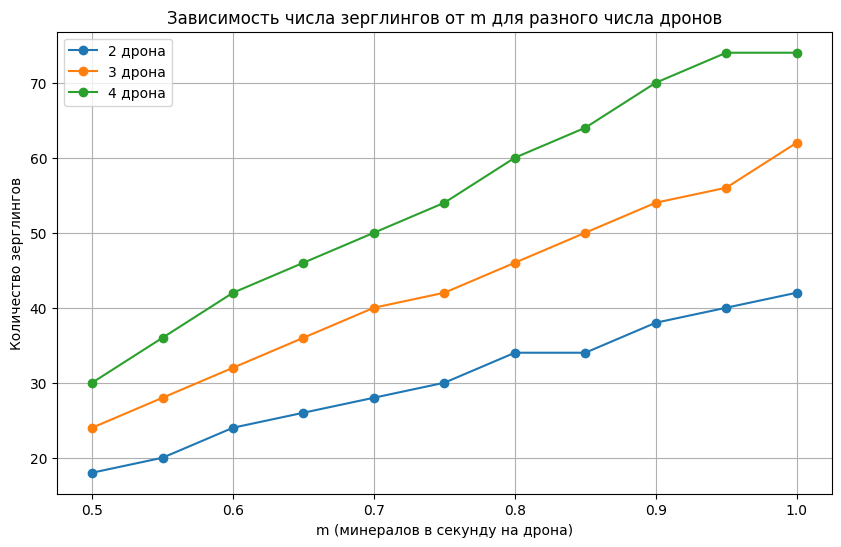


Оптимальное число дронов в зависимости от m:
  m = 0.95 .. 1.00 : 4 дрона


In [6]:
def simulate_strategy(m, n_drones, drone_times):
    
    dt = 15
    T = 600
    n_steps = T // dt
    D = 0
    L = 1
    M = 50
    Z = 0
    drone_idx = 0
    
    for step in range(n_steps + 1):
        t = step * dt
        
        while drone_idx < n_drones and abs(drone_times[drone_idx] - t) < 1e-6:
            if L > 0 and M >= 50:
                D += 1
                L -= 1
                M -= 50
                drone_idx += 1
            else:
                return -1
                
        if step < n_steps:
            M += int(m * dt * D)
            L += 1
            
    max_pairs = min(L, M // 50)
    Z += 2 * max_pairs
    
    return Z

def optimal_drone_times(m, n_drones):
    
    times = []
    D = 0
    M = 50
    t = 0
    dt = 15
    step = 0
    
    while len(times) < n_drones and step <= 40:
        if M >= 50:
            times.append(step * dt)
            D += 1
            M -= 50
            
        M += int(m * dt * D)
        step += 1
    return times

m_values = [i/20 for i in range(10, 21)]
results = {2: [], 3: [], 4: []}

for m in m_values:
    for nd in [2, 3, 4]:
        t_drones = optimal_drone_times(m, nd)
        
        if len(t_drones) == nd:
            z = simulate_strategy(m, nd, t_drones)
            results[nd].append(z)
        else:
            results[nd].append(0)

plt.figure(figsize=(10, 6))

for nd in [2, 3, 4]:
    plt.plot(m_values, results[nd], marker='o', label=f'{nd} дрона')
    
plt.xlabel('m (минералов в секунду на дрона)')
plt.ylabel('Количество зерглингов')
plt.title('Зависимость числа зерглингов от m для разного числа дронов')
plt.legend()
plt.grid(True)
plt.show()

optimal_nd = []
for i, m in enumerate(m_values):
    z2 = results[2][i]
    z3 = results[3][i]
    z4 = results[4][i]
    best = max((z2,2), (z3,3), (z4,4))
    optimal_nd.append(best[1])

print("\nОптимальное число дронов в зависимости от m:")
for i in range(len(m_values)-1):
    if optimal_nd[i] != optimal_nd[i+1]:
        print(f"  m = {m_values[i]:.2f} .. {m_values[i+1]:.2f} : {optimal_nd[i]} дрона")
        
print(f"  m = {m_values[-2]:.2f} .. {m_values[-1]:.2f} : {optimal_nd[-1]} дрона")

m_low, m_high = None, None

for i, nd in enumerate(optimal_nd):
    if nd == 3:
        if m_low is None:
            m_low = m_values[i]
            
        m_high = m_values[i]